# Classification of b-quark jets in the Aleph simulated data

The following is an introduction to using Machine Learning (ML) - in particular Boosted Decision Trees (BDT) - for trying to determine, if an entry in a data file is of one type (signal, ill, guilty, etc.) or another (background, healthy, innocent, etc.).

You may choose between two data samples:
1. A particle physics dataset containing simulated decays of the $Z^0$ boson decaying to a quark and an anti-quark producing two "jets" of particles. The question is, if the jets are from a b-quark (b-jet) or from lighter quarks (l-jet).
3. A "medical" dataset which concers a lifestyle disease in relation to various (transformed) lifestyle variables (reduced in number of variables to match the Aleph b-jet data set).

In the following, we discuss the problem from the b-jet point of view, as this is where the largest size datasets are available. However, we stress that from the point of view of ML, data content (what is being considered) is not essential to know (for now!!!). And knowing the content in details requires domain knowledge, i.e. that you are an expert in the specific field, that the data comes from. This part is very important, but not the focus in this course.

In the end, this exercise is the simple start "outside ML" and moving into the territory of Machine Learning analysis.

### The Data:
The input variables (X) are (used by Aleph for their NN):
* **prob_b**: Probability of being a b-jet from the pointing of the tracks to the vertex.
* **spheri**: Sphericity of the event, i.e. how spherical it is.
* **pt2rel**: The transverse momentum squared of the tracks relative to the jet axis, i.e. width of the jet.
* **multip**: Multiplicity of the jet (in a relative measure).
* **bqvjet**: b-quark vertex of the jet, i.e. the probability of a detached vertex.
* **ptlrel**: Transverse momentum (in GeV) of possible lepton with respect to jet axis (about 0 if no leptons).

Auxilary variables (Z) are (not used by Aleph for their NN):
* energy: Measured energy of the jet in GeV. Should be 45 GeV, but fluctuates.
* cTheta: cos(theta), i.e. the polar angle of the jet with respect to the beam axis. Note, that the detector works best in the central region (|cTheta| small) and less well in the forward regions.
* phi:    The azimuth angle of the jet. As the Aleph detector was essentially uniform in phi, this should not matter (much).

The target variable (Y) is:
* **isb**:    1 if it is from a b-quark and 0, if it is not.

Finally, those before you (the Aleph collaboration in the mid 90'ies) produced a Neural Net (6 input variables, two hidden layers with 10 neurons in each, and 1 output varible) based classification variable, which you can compare to (and compete with?):
* **nnbjet**: Value of original Aleph b-jet tagging algorithm, using only the last six variables (for reference).

In case you choose **the medical data**, the variables to use as input (X) are: **Qsocial, BMI, Roccupat, Rgenetic, Rdietary, and Rhormonn** (reflecting Quantiles and Ratios of medical measurements). The target variable (Y) is (naturally): **TrulyIll**, and you can compare your results to the average of doctors: **DocScore**.


### The Task:
Thus, the task before you is to produce functions (non-ML and ML algorithm), which given the input variables X provides an output variable estimate, Y_est, which is "closest possible" to the target variable, Y. The "closest possible" is left to the user to define in a _Loss Function_, which we will discuss further later. In classification problems (such as this), the typical loss function to use is ["Cross Entropy"](https://en.wikipedia.org/wiki/Cross_entropy).

You should approach the problem in two ways:
* Initially (i.e. first 15-30 minutes), simply with "if"-statements making requirements on certain variables. This corresponds to selecting "boxes" in the input variable space (typically called "X"). One could also try a linear combination of input variables (i.e. a Fisher discriminant), which corresponds to a plane in the X-space. Such a solution is fast and transparent (very good), but as the data contains non-linear correlations, it is likely to approximate.<br>
**The point of this step is NOT to make a great algorith, but rather to set up comparing different algorithms!**

* Next using Machine Learning (ML) methods. We will during the first week try both Boosted Decision Tree (BDT) based and Neural Net (NN) based methods, and see how complicated (or not) it is to get a good solution, and how much better it performs compared to the "classic" selection method.

Once you obtain a classification of b-jets vs. non-b-jets, think about how to quantify the quality of your algorithm. Once you have a "metric" for doing so, try to compare it to the NN result of the Aleph collaboration, given by the variable "nnbjet". It is based on a neural network with 6 input variables (prob_b, spheri, pt2rel, multip, bqvjet, and ptlrel), and two hidden layers each with 10 nodes in. Can you do better?

Don't hold back in drawing inspiration from "ML_MethodsDemos.ipynb" (in Week0) or the vast internet. BDT suggestions might be [XGBoost](https://xgboost.readthedocs.io/en/release_3.0.0/) or [LightGBM](https://lightgbm.readthedocs.io/en/stable/). NN suggestions might be [PyTorch](https://pytorch.org/) or [TensorFlow](https://www.tensorflow.org/).

* Author: Troels C. Petersen (NBI)
* Email:  petersen@nbi.dk
* Date:   15th of April 2026

In [1]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np

SavePlots = False

## Import and inspect the data:

In [2]:
# Read the data and print the variables:
# data = pd.DataFrame(np.genfromtxt('AlephBtag_MC_train_Nev50000.csv', names=True))
data = pd.DataFrame(np.genfromtxt('AlephBtag_MC_train_Nev5000000.csv', names=True, delimiter=','))
# data = pd.DataFrame(np.genfromtxt('Medical_Npatients5000.csv', names=True))

variables = data.columns
print(variables.values)

# Decide on which variables to use for input (X) and what defines the label (Y):
input_variables = variables[(variables != 'nnbjet') & (variables != 'isb') & (variables != 'energy') & (variables != 'cTheta') & (variables != 'phi')]
input_data      = data[input_variables]
truth_data      = data['isb']
benchmark_data  = data['nnbjet']
print("  Variables used for training: ", input_variables.values)

['energy' 'cTheta' 'phi' 'prob_b' 'spheri' 'pt2rel' 'multip' 'bqvjet'
 'ptlrel' 'nnbjet' 'isb']
  Variables used for training:  ['prob_b' 'spheri' 'pt2rel' 'multip' 'bqvjet' 'ptlrel']


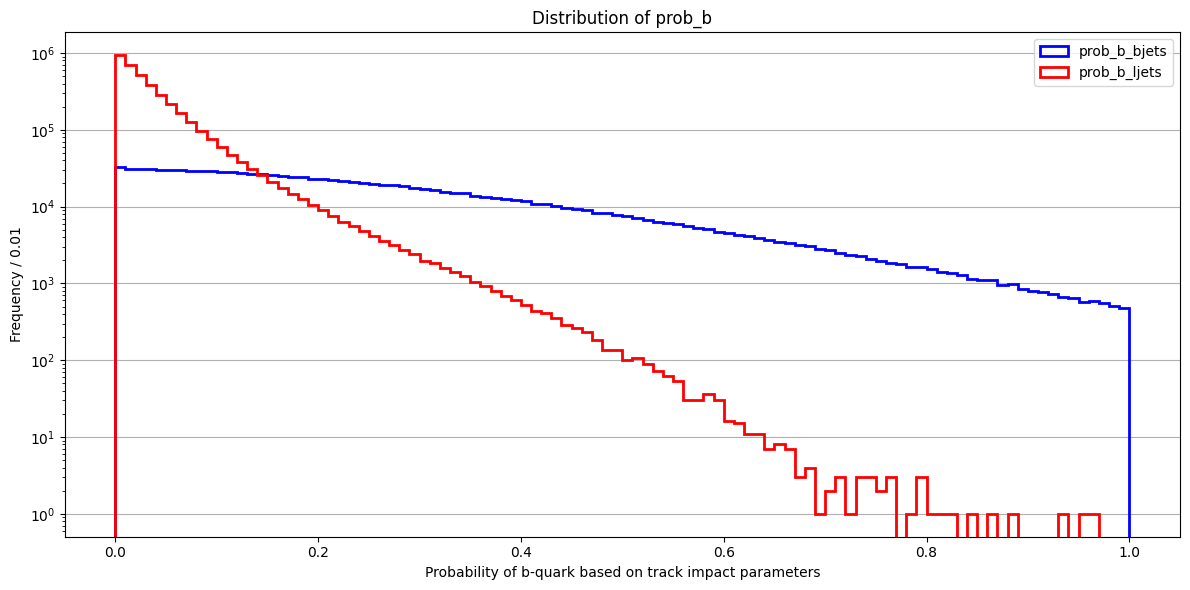

In [3]:
# Look at the distribution of the input variables for each event type:
mask = (data['isb'] == 1)      # Mask to divide the event types

fig, ax = plt.subplots(figsize=(12, 6))
hist_prob_b_bjets = ax.hist(data['prob_b'][mask],  bins=100, range=(0.0, 1.0), histtype='step', linewidth=2, label='prob_b_bjets', color='blue')
hist_prob_b_ljets = ax.hist(data['prob_b'][~mask], bins=100, range=(0.0, 1.0), histtype='step', linewidth=2, label='prob_b_ljets', color='red')
ax.set_xlabel("Probability of b-quark based on track impact parameters")
ax.set_ylabel("Frequency / 0.01")
ax.set_title("Distribution of prob_b")
ax.set_yscale("log")
ax.legend(loc='best')
ax.grid(axis='y')
fig.tight_layout()

if SavePlots :
    fig.savefig('Hist_prob_b.pdf', dpi=600)

## Selection:

Imagine that you had never heard of Machine Learning (ML), and had to select b-jets without! This would probably boil down to doing so simply based on "if"-sentences, as shown below: 

In [4]:
# Give the variables logic names, and define them early, so that they only need to be changed
# in ONE place (also to ensures consistency!):
cut_prop_b  = 0.15

# If prob_b indicate b-quark, call it a b-quark, otherwise not! You can expand on this yourself at will.
bquark=[]
for i in np.arange(len(data['prob_b'])):
    if (data['prob_b'][i] > cut_prop_b) : bquark.append(1)
    else : bquark.append(0)

## Evaluate the selection:

In [5]:
def evaluate(bquark) :
    N = [[0,0], [0,0]]   # Make a list of lists (i.e. confusion matrix) for counting successes/failures.
    for i in np.arange(len(data['isb'])):
        if (bquark[i] == 0 and data['isb'][i] == 0) : N[0][0] += 1
        if (bquark[i] == 0 and data['isb'][i] == 1) : N[0][1] += 1
        if (bquark[i] == 1 and data['isb'][i] == 0) : N[1][0] += 1
        if (bquark[i] == 1 and data['isb'][i] == 1) : N[1][1] += 1
    fracWrong = float(N[0][1]+N[1][0])/float(len(data['isb']))
    accuracy = 1.0 - fracWrong
    return N, accuracy, fracWrong

In [6]:
N, accuracy, fracWrong = evaluate(bquark)
print("\nRESULT OF HUMAN ATTEMPT AT A SELECTION:")
print("  First number in parenthesis is the estimate, second is the MC truth (i.e. label):")
print("  True-Negative (0,0)  = ", N[0][0])
print("  False-Negative (0,1) = ", N[0][1])
print("  False-Positive (1,0) = ", N[1][0])
print("  True-Positive (1,1)  = ", N[1][1])
print("    Fraction wrong            = ( (0,1) + (1,0) ) / sum = ", fracWrong)
print("    Fraction right (accuracy) = ( (0,0) + (1,1) ) / sum = ", accuracy)


RESULT OF HUMAN ATTEMPT AT A SELECTION:
  First number in parenthesis is the estimate, second is the MC truth (i.e. label):
  True-Negative (0,0)  =  3714343
  False-Negative (0,1) =  439484
  False-Positive (1,0) =  140645
  True-Positive (1,1)  =  705528
    Fraction wrong            = ( (0,1) + (1,0) ) / sum =  0.1160258
    Fraction right (accuracy) = ( (0,0) + (1,1) ) / sum =  0.8839742


In [7]:
# Compare with Aleph NN-approach from 1990'ies (choosing a reasonable selection cut on "nnbjet"):
bquark=[]
for i in np.arange(len(data['nnbjet'])):
    if   (data['nnbjet'][i] > 0.82) : bquark.append(1)
    else : bquark.append(0)

N, accuracy, fracWrong = evaluate(bquark)
print("\nALEPH BJET TAG:")
print("  First number in parenthesis is the estimate, second is the MC truth (i.e. label):")
print("  True-Negative (0,0)  = ", N[0][0])
print("  False-Negative (0,1) = ", N[0][1])
print("  False-Positive (1,0) = ", N[1][0])
print("  True-Positive (1,1)  = ", N[1][1])
print("    Fraction wrong            = ( (0,1) + (1,0) ) / sum = ", fracWrong)
print("    Fraction right (accuracy) = ( (0,0) + (1,1) ) / sum = ", accuracy)


ALEPH BJET TAG:
  First number in parenthesis is the estimate, second is the MC truth (i.e. label):
  True-Negative (0,0)  =  3721061
  False-Negative (0,1) =  356165
  False-Positive (1,0) =  133927
  True-Positive (1,1)  =  788847
    Fraction wrong            = ( (0,1) + (1,0) ) / sum =  0.0980184
    Fraction right (accuracy) = ( (0,0) + (1,1) ) / sum =  0.9019816


## Questions:

1. Start by plotting the six "Aleph classification variables" and calculate their correlation matrices for signal and background, and see which seems to separate and correlate most (optional).

2. Above, the scoring is simply done by considering the fraction of wrong estimates. Think about what the alternatives could be, especially if you were to give a continuous score like the Aleph-NN. This scoring is called the "loss function".

3. <b>Draw ROC curves for each of these six separately, to quantify the separation. Also draw the Aleph-NN variable (nnbjet).</b> Is the Aleph-NN better? Are any of the variables "seemingly worthless"? (we will return to this point later).<br>
Note that decision variables (i.e. 0 and 1) yield a single point in the ROC curve plot.

5. <b>Try to get a BDT to make predictions based on the six given input variables. Plot the result in the ROC curve, and see if you managed to compete or even improve upon the Aleph-NN scores.</b>

6. <b>Think about what data you based your predictions on? Was it the same data that you trained the algorithm on? And if that is the case, is that reasonable?<b>

7. Does including more data (50000 instead of 5000 events) improve your performance?

8. Does including the kinematic variables 'energy', 'cTheta', and 'phi' (which are not related to jet type) improve your performance?

## Learning points:

From this exercise you should:

1. get a feel for the problem at hand, namely to separate two populations in a 6-dimensional space. It is hard to imagine, yet with simple cuts you should be able to get "some performance", though never close to the Aleph-NN.

2. learn, that it is hard to do "by hand", but that at least the fact that you have known cases (i.e. labels) makes you capable of getting some performance.

3. be able to draw ROC curves to compare performances between different variables and scores (floating or discrete).

4. know that you can (typically) improve the performance through the use of Machine Learning (ML).

5. <b>be capable not only of getting ML results, but also confident in optimising them, and certainly proficient in interpreting them.</b>

# Code for solution attempts:

Note: I do not validate any of my models; I only split into a training and a testing dataset. Daniel is working on a function that will easily split data into three sets for training, validation, and testing.

In [8]:
## Imports for solutions
import xgboost as xgb
import lightgbm as lgb 
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score

In [9]:
# Split data to get a subset for training
# Also split the benchmark data for comparison
X_train, X_test, y_train, y_test, bench_train, bench_test = train_test_split(
    input_data,
    truth_data,
    benchmark_data,
    test_size=0.3,
    random_state=69,
    stratify=truth_data
)

## Aleph NN approach

In [10]:
## Aleph NN approach

# Compare training predictions with subset
nn_pred = (bench_test > 0.82).astype(int)

print("Confusion matrix:")
print(confusion_matrix(y_test, nn_pred))
print("Accuracy:", accuracy_score(y_test, nn_pred))
print("ROC AUC:", roc_auc_score(y_test, bench_test))

Confusion matrix:
[[1116184   40312]
 [ 107109  236395]]
Accuracy: 0.9017193333333333
ROC AUC: 0.9303103238054183


## [XGBoost](https://xgboost.readthedocs.io/en/) implementation


In [11]:
## XGB Model
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.05,
    max_depth=4,
    n_estimators=200,
    eval_metric='logloss',
    seed=69
)

# Train
xgb_clf.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_clf.predict(X_test)
y_score_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# Metrics
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_score_xgb))

Confusion matrix:
[[1113690   42806]
 [ 102384  241120]]
Accuracy: 0.9032066666666667
ROC AUC: 0.9343796208769317


## [LightGBM](https://lightgbm.readthedocs.io/en/stable/) implementation
Below, there are two different versions with different syntax.

In [12]:
## LightGBM Model - OLD VERSION
# uses lgb.train

# Train dataset
data_train = lgb.Dataset(X_train, label=y_train)

# Parameters
params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'metric': 'binary_logloss',
    'learning_rate': 0.05,
    'num_leaves': 15,
    'max_depth': 4,
    'min_data_in_leaf': 10,
    'verbose': -1,
    'force_col_wise': True,
    'seed': 69
}

# Train
lgb_clf = lgb.train(params, train_set=data_train, num_boost_round=300)

# Predictions
y_score_lgb = lgb_clf.predict(X_test)
y_pred_lgb = (y_score_lgb >= 0.5).astype(int)

# Metrics
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lgb))
print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("ROC AUC:", roc_auc_score(y_test, y_score_lgb))

Confusion matrix:
[[1113651   42845]
 [ 101423  242081]]
Accuracy: 0.9038213333333334
ROC AUC: 0.9353950486762513


In [13]:
## LightGBM Model - MORE COMPATIBLE WITH XGB SETUP SYNTAX (for comparison)
# uses LGBMClassifier 

lgbm_clf = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    learning_rate=0.05,
    n_estimators=200,
    max_depth=4,
    num_leaves=15,
    min_child_samples=10,
    random_state=69,
    verbose=-1,
    force_col_wise=True
)

# Train
lgbm_clf.fit(X_train, y_train)

# Predictions
y_pred_lgb = lgbm_clf.predict(X_test)
y_score_lgb = lgbm_clf.predict_proba(X_test)[:, 1]

# Metrics
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lgb))
print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("ROC AUC:", roc_auc_score(y_test, y_score_lgb))

Confusion matrix:
[[1113761   42735]
 [ 102438  241066]]
Accuracy: 0.903218
ROC AUC: 0.9344616812499289


# [PyTorch](https://docs.pytorch.org/docs/stable/index.html) Neural Networks implementation

Let's start by scaling the data. Neural networks like to work with training data in the neighborhood of 0. For this particular problem, most of the data already lies around 0, but we rescale here in case we want to reuse this code for a later project.

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
# Scale inputs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

y_train_np = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)
y_test_np = np.asarray(y_test, dtype=np.float32).reshape(-1, 1)


We will define the neural network below. **IMPORTANT:** on my machine, I must set the number of threads that PyTorch uses to 1 or 2; otherwise, I run into what I believe could be CPU oversubscription. PyTorch’s docs explicitly warn that too many concurrent processes or threads can cause CPU oversubscription, where more threads/processes are competing for CPU than the machine can efficiently handle.

### Loss function and optimizer

We use `nn.BCEWithLogitsLoss()` as the loss function because this is a **binary classification** problem. The network outputs a raw score (a *logit*) for each event, and this loss function internally applies a sigmoid transformation and then computes the binary cross-entropy error relative to the true label. In other words, it measures how wrong the model is, with larger penalties for confident wrong predictions.

We use `Adam(model.parameters(), lr=1e-3)` as the optimizer. The optimizer is the part of training that updates the network weights after backpropagation has computed gradients. Adam is a widely used gradient-based optimizer that adapts the update size for each parameter during training. The learning rate `lr=1e-3` sets the overall step size of these updates.

In [16]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader

torch.set_num_threads(1) # Use 1 or 2 threads

In [17]:
# Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32)

# Loader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)

# Model
n_inputs = X_train_scaled.shape[1]
model = nn.Sequential(
    nn.Linear(n_inputs, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

Next, we train the model. To connect with Troels's lecture: if we wanted to add a learning rate scheduler, we could do it in principle in the code block below.

In [18]:
n_epochs = 20

# Training
for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    with torch.no_grad():
        logits_test = model(X_test_tensor)
        y_score_test = torch.sigmoid(logits_test).numpy().ravel()
        test_auc = roc_auc_score(y_test_np.ravel().astype(int), y_score_test)

    print(f"Epoch {epoch+1:2d}/{n_epochs} - train loss: {train_loss:.5f} - test AUC: {test_auc:.4f}")

Epoch  1/20 - train loss: 0.25094 - test AUC: 0.9335
Epoch  2/20 - train loss: 0.24833 - test AUC: 0.9338
Epoch  3/20 - train loss: 0.24794 - test AUC: 0.9339
Epoch  4/20 - train loss: 0.24769 - test AUC: 0.9340
Epoch  5/20 - train loss: 0.24759 - test AUC: 0.9341
Epoch  6/20 - train loss: 0.24748 - test AUC: 0.9342
Epoch  7/20 - train loss: 0.24741 - test AUC: 0.9341
Epoch  8/20 - train loss: 0.24736 - test AUC: 0.9341
Epoch  9/20 - train loss: 0.24732 - test AUC: 0.9341
Epoch 10/20 - train loss: 0.24727 - test AUC: 0.9342
Epoch 11/20 - train loss: 0.24727 - test AUC: 0.9343
Epoch 12/20 - train loss: 0.24722 - test AUC: 0.9342
Epoch 13/20 - train loss: 0.24722 - test AUC: 0.9341
Epoch 14/20 - train loss: 0.24720 - test AUC: 0.9341
Epoch 15/20 - train loss: 0.24718 - test AUC: 0.9341
Epoch 16/20 - train loss: 0.24716 - test AUC: 0.9342
Epoch 17/20 - train loss: 0.24714 - test AUC: 0.9342
Epoch 18/20 - train loss: 0.24712 - test AUC: 0.9342
Epoch 19/20 - train loss: 0.24712 - test AUC: 

Finally, we characterize the PyTorch model in the same way we evaluated the others: with a confusion matrix, an accuracy score, and an AUC of the ROC curve.

In [19]:
# Evaluation mode
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)                           # raw logits
    y_score_torch = torch.sigmoid(logits).numpy().ravel()   # probabilities
    y_pred_torch = (y_score_torch >= 0.5).astype(int)       # hard predictions

# Metrics
print("Confusion matrix:")
print(confusion_matrix(y_test_np, y_pred_torch))
print("Accuracy:", accuracy_score(y_test_np, y_pred_torch))
print("ROC AUC:", roc_auc_score(y_test_np, y_score_torch))

Confusion matrix:
[[1117449   39047]
 [ 105454  238050]]
Accuracy: 0.903666
ROC AUC: 0.9342311903697702


## Plotting

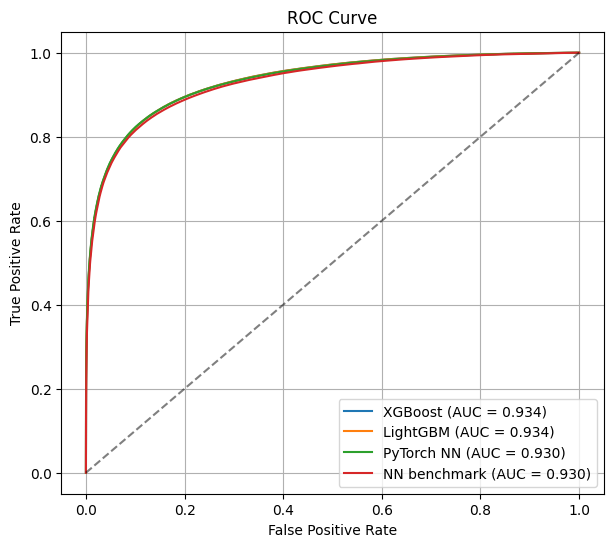

In [20]:
## Plotting, ROC curve

# ROC curves
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_score_xgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_score_lgb)
fpr_torch, tpr_torch, _ = roc_curve(y_test_np.ravel().astype(int), y_score_torch)
fpr_nn, tpr_nn, _ = roc_curve(y_test, bench_test)

# AUCs
auc_xgb = roc_auc_score(y_test, y_score_xgb)
auc_lgb = roc_auc_score(y_test, y_score_lgb)
auc_torch = roc_auc_score(y_test, y_score_torch)
auc_nn = roc_auc_score(y_test, bench_test)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.3f})')
plt.plot(fpr_torch, tpr_torch, label=f'PyTorch NN (AUC = {auc_nn:.3f})')
plt.plot(fpr_nn, tpr_nn, label=f'NN benchmark (AUC = {auc_nn:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()